NEURAL NETWORKS
A Computational model inspired by biological nuerons.


Basic Neural Network with One Hidden Layer

In [ ]:
import numpy as np

# Sigmoid activation function and its derivative
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# Define the dataset
# Inputs (X) and outputs (y) for a simple XOR problem
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])

y = np.array([[0], [1], [1], [0]])

# Seed for reproducibility
np.random.seed(42)

# Initialize weights randomly with mean 0
input_layer_neurons = X.shape[1]  # Number of input features
hidden_layer_neurons = 4          # Number of neurons in the hidden layer
output_neurons = y.shape[1]       # Number of neurons in the output layer

weights_input_hidden = np.random.uniform(-1, 1, (input_layer_neurons, hidden_layer_neurons))
weights_hidden_output = np.random.uniform(-1, 1, (hidden_layer_neurons, output_neurons))

# Biases
bias_hidden = np.random.uniform(-1, 1, (1, hidden_layer_neurons))
bias_output = np.random.uniform(-1, 1, (1, output_neurons))

# Learning rate
lr = 0.1

# Training the network
epochs = 10000  # Number of iterations
for epoch in range(epochs):
    # Forward pass
    hidden_layer_input = np.dot(X, weights_input_hidden) + bias_hidden
    hidden_layer_output = sigmoid(hidden_layer_input)

    output_layer_input = np.dot(hidden_layer_output, weights_hidden_output) + bias_output
    predicted_output = sigmoid(output_layer_input)

    # Compute the error
    error = y - predicted_output

    # Backpropagation
    d_predicted_output = error * sigmoid_derivative(predicted_output)
    error_hidden_layer = d_predicted_output.dot(weights_hidden_output.T)
    d_hidden_layer = error_hidden_layer * sigmoid_derivative(hidden_layer_output)

    # Update weights and biases
    weights_hidden_output += hidden_layer_output.T.dot(d_predicted_output) * lr
    weights_input_hidden += X.T.dot(d_hidden_layer) * lr
    bias_output += np.sum(d_predicted_output, axis=0, keepdims=True) * lr
    bias_hidden += np.sum(d_hidden_layer, axis=0, keepdims=True) * lr

    # Optional: Print loss at intervals
    if epoch % 1000 == 0:
        loss = np.mean(np.square(error))
        print(f"Epoch {epoch} - Loss: {loss:.4f}")

# Testing the network
print("\nFinal Predicted Output:")
print(predicted_output.round(2))  # Rounded for clarity


Epoch 0 - Loss: 0.2522
Epoch 1000 - Loss: 0.2392
Epoch 2000 - Loss: 0.1508
Epoch 3000 - Loss: 0.0286
Epoch 4000 - Loss: 0.0109
Epoch 5000 - Loss: 0.0062
Epoch 6000 - Loss: 0.0043
Epoch 7000 - Loss: 0.0032
Epoch 8000 - Loss: 0.0025
Epoch 9000 - Loss: 0.0021

Final Predicted Output:
[[0.04]
 [0.96]
 [0.96]
 [0.04]]


Dataset:

Input (X): Represents the XOR problem, which is a common example to test basic neural networks.
Output (y): Target labels.

Network Architecture:

Input Layer: Takes two features as input.
Hidden Layer: Contains 4 neurons (can be adjusted).
Output Layer: Contains 1 neuron to predict binary output.

Activation Function:

Sigmoid: Used to introduce non-linearity and constrain outputs to a range of 0-1.

Training:

Forward Pass: Compute activations for hidden and output layers.

Backpropagation: Calculate the gradient of the loss concerning weights and biases.

Gradient Descent: Update weights and biases using a learning rate.
Testing:

After training, the network predicts outputs for the XOR dataset.

Epoch 0 - Loss: 0.2522
Epoch 1000 - Loss: 0.2392
Epoch 2000 - Loss: 0.1508
Epoch 3000 - Loss: 0.0286
Epoch 4000 - Loss: 0.0109
Epoch 5000 - Loss: 0.0062
Epoch 6000 - Loss: 0.0043
Epoch 7000 - Loss: 0.0032
Epoch 8000 - Loss: 0.0025
Epoch 9000 - Loss: 0.0021

Final Predicted Output:
[[0.04]
 [0.96]
 [0.96]
 [0.04]]


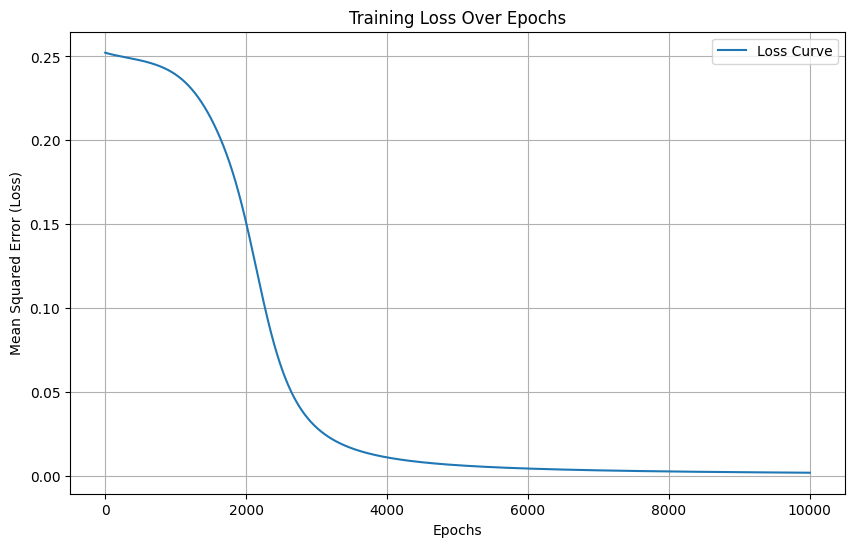

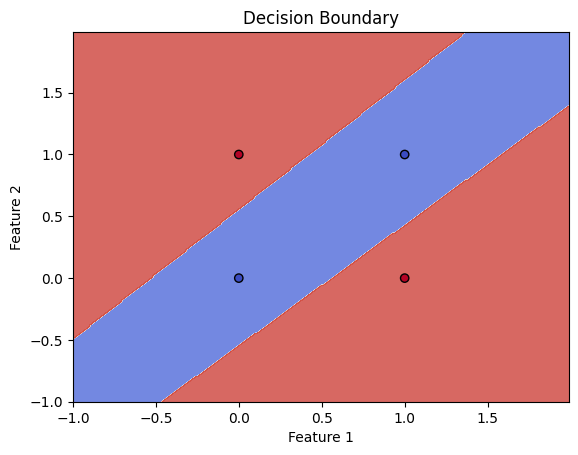

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sigmoid activation function and its derivative
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# Define the dataset
# Inputs (X) and outputs (y) for a simple XOR problem
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])

y = np.array([[0], [1], [1], [0]])

# Seed for reproducibility
np.random.seed(42)

# Initialize weights randomly with mean 0
input_layer_neurons = X.shape[1]  # Number of input features
hidden_layer_neurons = 4          # Number of neurons in the hidden layer
output_neurons = y.shape[1]       # Number of neurons in the output layer

weights_input_hidden = np.random.uniform(-1, 1, (input_layer_neurons, hidden_layer_neurons))
weights_hidden_output = np.random.uniform(-1, 1, (hidden_layer_neurons, output_neurons))

# Biases
bias_hidden = np.random.uniform(-1, 1, (1, hidden_layer_neurons))
bias_output = np.random.uniform(-1, 1, (1, output_neurons))

# Learning rate
lr = 0.1

# Training the network
epochs = 10000  # Number of iterations
losses = []  # To store the loss for visualization

for epoch in range(epochs):
    # Forward pass
    hidden_layer_input = np.dot(X, weights_input_hidden) + bias_hidden
    hidden_layer_output = sigmoid(hidden_layer_input)

    output_layer_input = np.dot(hidden_layer_output, weights_hidden_output) + bias_output
    predicted_output = sigmoid(output_layer_input)

    # Compute the error
    error = y - predicted_output
    loss = np.mean(np.square(error))
    losses.append(loss)  # Store the loss

    # Backpropagation
    d_predicted_output = error * sigmoid_derivative(predicted_output)
    error_hidden_layer = d_predicted_output.dot(weights_hidden_output.T)
    d_hidden_layer = error_hidden_layer * sigmoid_derivative(hidden_layer_output)

    # Update weights and biases
    weights_hidden_output += hidden_layer_output.T.dot(d_predicted_output) * lr
    weights_input_hidden += X.T.dot(d_hidden_layer) * lr
    bias_output += np.sum(d_predicted_output, axis=0, keepdims=True) * lr
    bias_hidden += np.sum(d_hidden_layer, axis=0, keepdims=True) * lr

    # Optional: Print loss at intervals
    if epoch % 1000 == 0:
        print(f"Epoch {epoch} - Loss: {loss:.4f}")

# Testing the network
print("\nFinal Predicted Output:")
print(predicted_output.round(2))  # Rounded for clarity

losses=[]
losses.append(loss)

# Visualize the loss curve
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), losses, label='Loss Curve')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error (Loss)")
plt.grid()
plt.legend()
plt.show()

# Visualize the decision boundary
def plot_decision_boundary(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    Z = model(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), edgecolors='k', cmap='coolwarm')
    plt.title("Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

# Define a simple prediction function for the trained model
def model(X):
    hidden_layer_input = np.dot(X, weights_input_hidden) + bias_hidden
    hidden_layer_output = sigmoid(hidden_layer_input)
    output_layer_input = np.dot(hidden_layer_output, weights_hidden_output) + bias_output
    return sigmoid(output_layer_input).round()

plot_decision_boundary(X, y, model)


Predicting a Binary Output (Simple AND Gate)

In [ ]:
import numpy as np

# Sigmoid activation function and its derivative
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# Dataset: AND Gate
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])
y = np.array([[0], [0], [0], [1]])

# Initialize weights and biases
np.random.seed(1)
weights = np.random.rand(2, 1)
bias = np.random.rand(1)
lr = 0.1

# Training loop
losses = []
epochs = 10000

for epoch in range(epochs):
    # Forward pass
    z = np.dot(X, weights) + bias
    predicted_output = sigmoid(z)

    # Calculate error
    error = y - predicted_output
    loss = np.mean(np.square(error))
    losses.append(loss)

    # Backpropagation
    d_output = error * sigmoid_derivative(predicted_output)
    weights += np.dot(X.T, d_output) * lr
    bias += np.sum(d_output) * lr

    if epoch % 1000 == 0:
        print(f"Epoch {epoch} - Loss: {loss:.4f}")

# Test the network
print("\nFinal Predictions:")
print(predicted_output.round(2))


Epoch 0 - Loss: 0.2812
Epoch 1000 - Loss: 0.0312
Epoch 2000 - Loss: 0.0155
Epoch 3000 - Loss: 0.0100
Epoch 4000 - Loss: 0.0073
Epoch 5000 - Loss: 0.0057
Epoch 6000 - Loss: 0.0046
Epoch 7000 - Loss: 0.0039
Epoch 8000 - Loss: 0.0034
Epoch 9000 - Loss: 0.0030

Final Predictions:
[[0.  ]
 [0.06]
 [0.06]
 [0.93]]


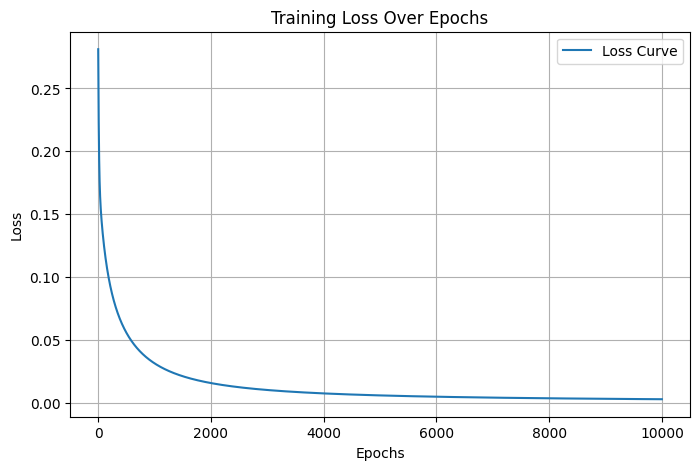

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(epochs), losses, label="Loss Curve")
plt.title("Training Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid()
plt.legend()
plt.show()


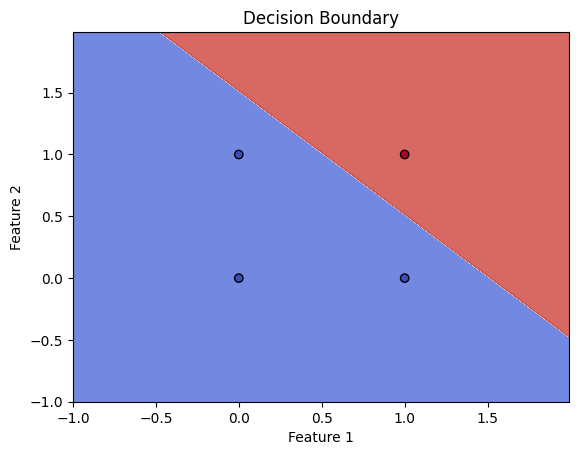

In [ ]:
def plot_decision_boundary(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    Z = model(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), edgecolors='k', cmap='coolwarm')
    plt.title("Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

# Prediction function for decision boundary
def model(X):
    z = np.dot(X, weights) + bias
    return (sigmoid(z) > 0.5).astype(int)

plot_decision_boundary(X, y, model)


Mean Squared Error (MSE)

In [ ]:
import numpy as np

# True and predicted values
y_true = np.array([1.5, 2.3, 3.0, 4.0])
y_pred = np.array([1.4, 2.5, 2.8, 3.9])

# Mean Squared Error
mse = np.mean((y_true - y_pred)**2)
print(f"Mean Squared Error: {mse:.4f}")


Mean Squared Error: 0.0250


Binary Cross-Entropy

In [ ]:
from sklearn.metrics import log_loss

# True labels and predicted probabilities
y_true = [1, 0, 1, 1]
y_pred = [0.9, 0.2, 0.8, 0.7]

# Binary Cross-Entropy
bce = log_loss(y_true, y_pred)
print(f"Binary Cross-Entropy: {bce:.4f}")


Binary Cross-Entropy: 0.2271


Categorical Cross-Entropy

In [ ]:
from sklearn.metrics import log_loss
import numpy as np

# True labels (one-hot encoded) and predicted probabilities
y_true = [[1, 0, 0], [0, 1, 0], [0, 0, 1]]
y_pred = [[0.7, 0.2, 0.1], [0.1, 0.8, 0.1], [0.2, 0.3, 0.5]]

# Categorical Cross-Entropy
cce = log_loss(y_true, y_pred)
print(f"Categorical Cross-Entropy: {cce:.4f}")


Categorical Cross-Entropy: 0.4243


Hinge Loss

In [ ]:
import numpy as np

# True labels and predicted scores
y_true = np.array([1, -1, 1, -1])
y_pred = np.array([0.8, -0.6, 0.4, -0.3])

# Hinge Loss
hinge_loss = np.mean(np.maximum(0, 1 - y_true * y_pred))
print(f"Hinge Loss: {hinge_loss:.4f}")


Hinge Loss: 0.4750


Binary Cross-Entropy Loss Surface

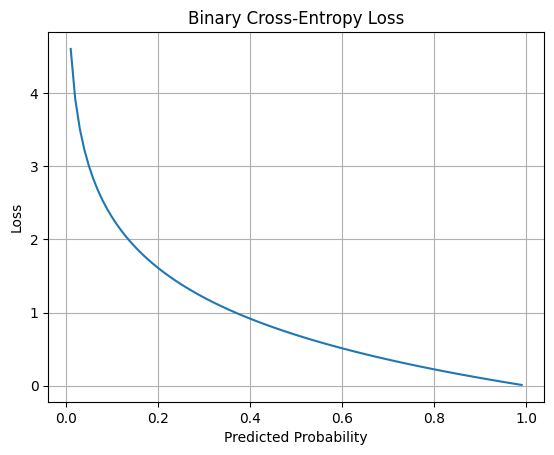

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss
y_true = 1  # True label
y_pred = np.linspace(0.01, 0.99, 100)


bce_loss = -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

plt.plot(y_pred, bce_loss)
plt.title("Binary Cross-Entropy Loss")
plt.xlabel("Predicted Probability")
plt.ylabel("Loss")
plt.grid()
plt.show()


Categorical Cross-Entropy

In [ ]:
from sklearn.metrics import log_loss
import numpy as np

# True labels (one-hot encoded) and predicted probabilities
y_true = [[1, 0, 0], [0, 1, 0], [0, 0, 1]]
y_pred = [[0.7, 0.2, 0.1], [0.1, 0.8, 0.1], [0.2, 0.3, 0.5]]

# Categorical Cross-Entropy
cce = log_loss(y_true, y_pred)
print(f"Categorical Cross-Entropy: {cce:.4f}")


Categorical Cross-Entropy: 0.4243


Categorical Cross-Entropy Loss Surface for Multi-Class

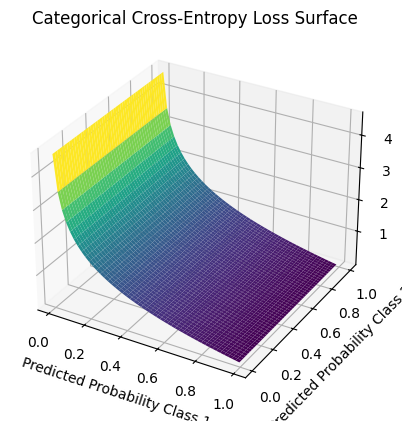

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

y_pred1 = np.linspace(0.01, 0.99, 50)
y_pred2 = np.linspace(0.01, 0.99, 50)
Y_pred1, Y_pred2 = np.meshgrid(y_pred1, y_pred2)

y_true = np.array([1, 0, 0])  # One-hot for class 1
loss = -y_true[0] * np.log(Y_pred1) - y_true[1] * np.log(Y_pred2)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(Y_pred1, Y_pred2, loss, cmap='viridis')
ax.set_title("Categorical Cross-Entropy Loss Surface")
ax.set_xlabel("Predicted Probability Class 1")
ax.set_ylabel("Predicted Probability Class 2")
ax.set_zlabel("Loss")
plt.show()


ACTIVATION FUNCTIONS

Rectified Linear Unit (ReLU)

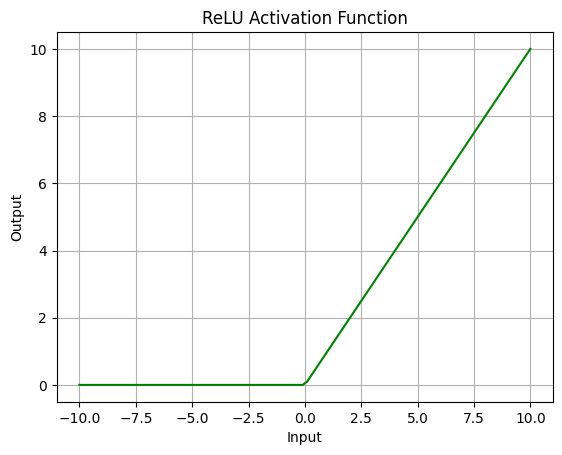

In [ ]:
x = np.linspace(-10, 10, 100)
relu = np.maximum(0, x)

plt.plot(x, relu, color='green')
plt.title("ReLU Activation Function")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid()
plt.show()


Leaky ReLU

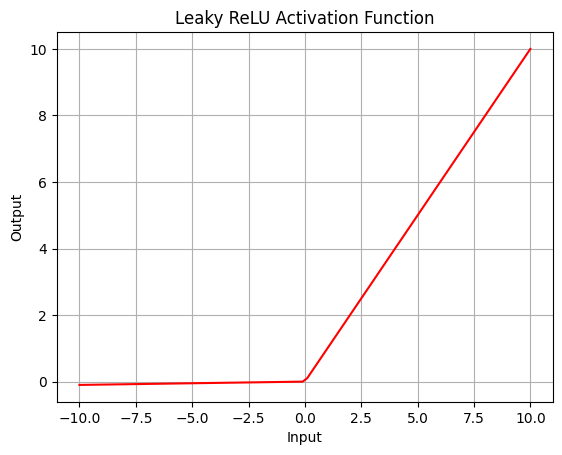

In [ ]:
alpha = 0.01
leaky_relu = np.where(x > 0, x, alpha * x)

plt.plot(x, leaky_relu, color='red')
plt.title("Leaky ReLU Activation Function")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid()
plt.show()


Softmax

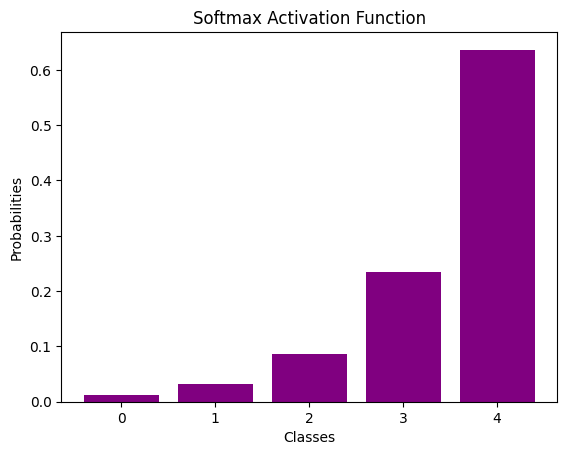

In [ ]:
def softmax(x):
    exp_x = np.exp(x - np.max(x))  # Stability adjustment
    return exp_x / exp_x.sum(axis=0)

x = np.array([1, 2, 3, 4, 5])
softmax_output = softmax(x)

plt.bar(range(len(x)), softmax_output, color='purple')
plt.title("Softmax Activation Function")
plt.xlabel("Classes")
plt.ylabel("Probabilities")
plt.show()


L1 Regularization (Lasso)

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.datasets import make_regression

# Generate sample data
X, y = make_regression(n_features=10, noise=0.1, random_state=42)

# Apply Lasso regression
model = Lasso(alpha=0.1)  # alpha is the regularization strength
model.fit(X, y)

print("Coefficients:", model.coef_)


Coefficients: [16.65093139 54.05831546  5.0204748  63.57011144 93.46899114 70.59900118
 86.94713107 10.25033395  3.09221178 70.77327962]


L2 Regularization (Ridge)

In [ ]:
from sklearn.linear_model import Ridge

# Apply Ridge regression
model = Ridge(alpha=0.1)
model.fit(X, y)

print("Coefficients:", model.coef_)


Coefficients: [16.76542499 54.09256452  5.16792341 63.57745649 93.49960668 70.60707101
 86.98982181 10.37927336  3.17943357 70.80578615]


Dropout

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Dropout, Dense
from tensorflow.keras.models import Sequential

# Neural network with Dropout
model = Sequential([
    Dense(128, activation='relu', input_shape=(100,)),
    Dropout(0.5),  # 50% of neurons dropped
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])
model.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │          12,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,834 (85.29 KB)

 Trainable params: 21,834 (85.29 KB)

 Non-trainable params: 0 (0.00 B)

Regularization Visualisation

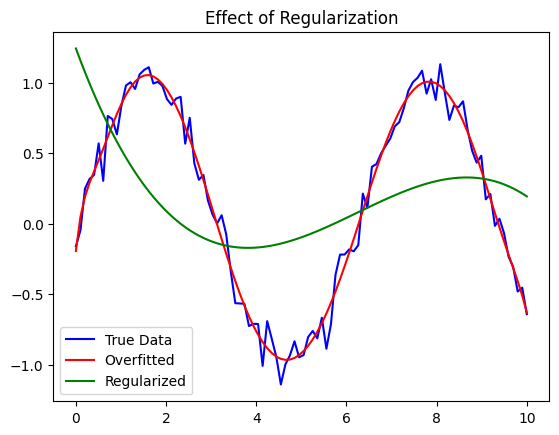

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 10, 100)
y_true = np.sin(x) + 0.1 * np.random.randn(100)
y_overfit = np.poly1d(np.polyfit(x, y_true, 15))(x)
y_regularized = np.poly1d(np.polyfit(x, y_true, 3))(x)

plt.plot(x, y_true, label="True Data", color='blue')
plt.plot(x, y_overfit, label="Overfitted", color='red')
plt.plot(x, y_regularized, label="Regularized", color='green')
plt.legend()
plt.title("Effect of Regularization")
plt.show()


Tokenization

Breaks down text into smaller units called tokens. Tokens can be as small as characters or as long as words.

Word Tokenization

In [ ]:
import nltk

from nltk.tokenize import word_tokenize
text = "The cat sat on the mat."
print(word_tokenize(text))
# Output: ['The', 'cat', 'sat', 'on', 'the', 'mat', '.']


['The', 'cat', 'sat', 'on', 'the', 'mat', '.']


Character Tokenization

In [ ]:
text = "The"
print(list(text))
# Output: ['T', 'h', 'e']


['T', 'h', 'e']


Sentence Tokenization

In [ ]:
from nltk.tokenize import sent_tokenize

text = "Hello everyone. You are studying tokenization."
sent_tokenize(text)

Subword Tokenization (e.g., Byte Pair Encoding - BPE)

In [ ]:
from transformers import AutoTokenizer

# Load a pre-trained tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

text = "The quick brown fox jumps over the lazy dog."
tokens = tokenizer.tokenize(text)
print(tokens)
# Output: ['the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog', '.']


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

['the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog', '.']


Word2Vec Embedding

In [ ]:
from gensim.models import Word2Vec

# Sample corpus
sentences = [
    ["king", "queen", "man", "woman"],
    ["prince", "princess", "boy", "girl"],
    ["cat", "dog", "puppy", "kitten"]
]

# Train Word2Vec model
model = Word2Vec(sentences, vector_size=10, window=5, min_count=1, workers=2)

# Get embedding for a word
word_vector = model.wv['king']

print("Embedding for 'king':\n", word_vector)

# Similarity between words
similarity = model.wv.similarity('king', 'queen')
print("\nSimilarity between 'king' and 'queen':", similarity)


[-0.01577653  0.00321372 -0.0414063  -0.07682689 -0.01508008  0.02469795
 -0.00888027  0.05533662 -0.02742977  0.02260065]


Visualisation

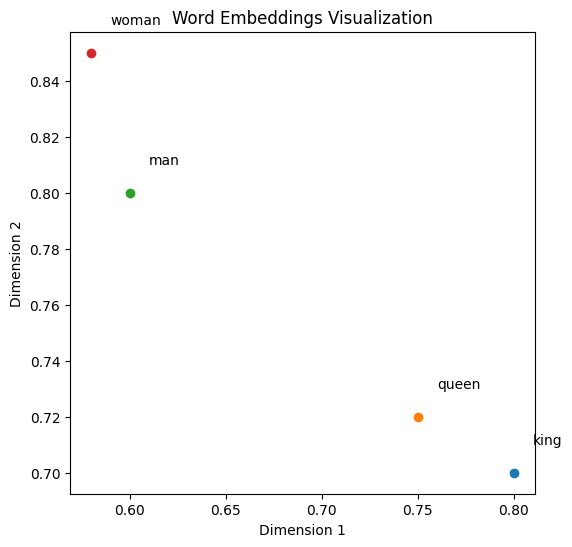

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Extract word vectors
words = list(model.wv.key_to_index)
word_vectors = [model.wv[word] for word in words]

# Reduce dimensions to 2D
pca = PCA(n_components=2)
word_vectors_2d = pca.fit_transform(word_vectors)

# Plot embeddings
plt.figure(figsize=(8, 6))
for i, word in enumerate(words):
    plt.scatter(word_vectors_2d[i, 0], word_vectors_2d[i, 1])
    plt.text(word_vectors_2d[i, 0] + 0.01, word_vectors_2d[i, 1], word, fontsize=12)

plt.title("Word Embeddings Visualization")
plt.show()


TRANSFORMERS

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F

# Example sequence
tokens = ["I", "love", "AI"]

# Dummy embeddings for tokens
embeddings = torch.tensor([[0.1, 0.2], [0.4, 0.3], [0.7, 0.8]])

# Query, Key, and Value matrices
Q = embeddings  # Query
K = embeddings  # Key
V = embeddings  # Value

# Compute attention scores
d_k = Q.shape[1]  # Dimension of key vectors
attention_scores = torch.matmul(Q, K.T) / np.sqrt(d_k)

# Apply softmax to get attention weights
attention_weights = F.softmax(attention_scores, dim=-1)

# Compute weighted sum of values
output = torch.matmul(attention_weights, V)

print("Attention Weights:\n", attention_weights)
print("Output:\n", output)


Attention Weights:
 tensor([[0.3153, 0.3266, 0.3581],
        [0.2892, 0.3216, 0.3892],
        [0.2429, 0.2982, 0.4590]])
Output:
 tensor([[0.4128, 0.4475],
        [0.4300, 0.4657],
        [0.4648, 0.5052]])


Positional Encoding

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
    pos_enc = pos * angle_rates
    pos_enc[:, 0::2] = np.sin(pos_enc[:, 0::2])  # Apply sin to even indices
    pos_enc[:, 1::2] = np.cos(pos_enc[:, 1::2])  # Apply cos to odd indices
    return pos_enc

# Parameters
seq_len = 50
d_model = 16

# Generate positional encodings
pos_enc = positional_encoding(seq_len, d_model)

# Visualize
plt.figure(figsize=(10, 8))
plt.pcolormesh(pos_enc, cmap='viridis')
plt.xlabel("Embedding Dimensions")
plt.ylabel("Sequence Length")
plt.title("Positional Encoding")
plt.colorbar()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def positional_encoding(max_len, d_model):
    """
    Generates positional encoding matrix for a given sequence length
    and embedding dimension.

    Args:
        max_len (int): Maximum sequence length.
        d_model (int): Dimension of embeddings.
    Returns:
        numpy.ndarray: Positional encoding matrix of
        shape (max_len, d_model).
    """
    position = np.arange(max_len).reshape(-1, 1)  # (max_len, 1)
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))  # (d_model/2,)

    pe = np.zeros((max_len, d_model))
    pe[:, 0::2] = np.sin(position * div_term)  # Apply sin to even indices
    pe[:, 1::2] = np.cos(position * div_term)  # Apply cos to odd indices
    return pe

# Generate positional encoding
max_len = 100
d_model = 16
pos_encoding = positional_encoding(max_len, d_model)

In [ ]:
# Plot sinusoidal waves for the first few dimensions
plt.figure(figsize=(12, 6))
for i in range(8):  # Visualize first 8 dimensions
    plt.plot(pos_encoding[:, i], label=f"Dimension {i}")
plt.title("Sinusoidal Waves of Positional Encoding")
plt.xlabel("Position in Sequence")
plt.ylabel("Value")
plt.legend()
plt.grid()
plt.show()

In [ ]:
import numpy as np

# Define input embeddings (3 words, embedding size 4)
inputs = np.array([[1, 0, 1, 0],
                   [0, 1, 0, 1],
                   [1, 1, 1, 1]])

# Define weights for Q, K, V
W_q = np.random.rand(4, 4)
W_k = np.random.rand(4, 4)
W_v = np.random.rand(4, 4)

# Compute Q, K, V
Q = np.dot(inputs, W_q)
K = np.dot(inputs, W_k)
V = np.dot(inputs, W_v)

# Compute Attention Scores (QK^T) and Scale
scores = np.dot(Q, K.T) / np.sqrt(K.shape[1])

# Apply Softmax to get attention weights
attention_weights = np.exp(scores) / np.sum(np.exp(scores), axis=1, keepdims=True)

# Compute the final output
output = np.dot(attention_weights, V)

print("Attention Weights:\n", attention_weights)
print("Output:\n", output)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(attention_weights, annot=True, cmap="coolwarm", cbar=True)
plt.title("Attention Weights Heatmap")
plt.xlabel("Keys")
plt.ylabel("Queries")
plt.show()

LLM Models

In [ ]:
from transformers import MarianMTModel, MarianTokenizer

# Load the pre-trained model and tokenizer
model_name = "Helsinki-NLP/opus-mt-en-fr"  # English to French translation model
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name)

# Input text for translation
text = "Hello, how are you today?"

# Tokenize the input text
inputs = tokenizer(text, return_tensors="pt", max_length=512, truncation=True)

# Generate translation using the model
translated = model.generate(**inputs)

# Decode the translated tokens
translated_text = tokenizer.decode(translated[0], skip_special_tokens=True)

# Print the output
print(f"Original Text: {text}")
print(f"Translated Text: {translated_text}")

In [ ]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# Load the pre-trained GPT-2 model and tokenizer
model_name = "gpt2"  # You can also use other LLMs like EleutherAI/gpt-neo
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name)

# Input prompt for the model
prompt = "Once upon a time in a distant galaxy,"

# Tokenize the input prompt
inputs = tokenizer(prompt, return_tensors="pt")

# Generate text
output = model.generate(
    inputs["input_ids"],
    max_length=50,  # Limit the length of generated text
    num_return_sequences=1,  # Number of output sequences
    no_repeat_ngram_size=2,  # Avoid repeating n-grams
    top_k=50,  # Consider only top_k tokens at each step
    top_p=0.95,  # Nucleus sampling
    temperature=1.0,  # Controls randomness
)

# Decode and print the generated text
generated_text = tokenizer.decode(output[0], skip_special_tokens=True)
print("Generated Text:")
print(generated_text)

In [ ]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# Load GPT-2 model and tokenizer
model = GPT2LMHeadModel.from_pretrained("gpt2")
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

# Function to generate text
def generate_text(prompt, max_length=50):
    inputs = tokenizer(prompt, return_tensors="pt")
    outputs = model.generate(inputs['input_ids'], max_length=max_length,
                             num_return_sequences=1)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Accept user input for the prompt
user_prompt = input("Enter your prompt: ")

# Generate text using the user's input
generated_text = generate_text(user_prompt)
print("\nGenerated Text:")
print(generated_text)

In [ ]:
from transformers import pipeline

# Load sentiment-analysis pipeline
classifier = pipeline("sentiment-analysis")

# Define the text for sentiment analysis (no user input)
text = "I love this product! It's amazing and works perfectly."

# Perform sentiment analysis
result = classifier(text)

# Print the result
print("Sentiment:", result)

In [ ]:
# Load question answering pipeline
qa = pipeline("question-answering")

# Define the context and the question
context = """The Python programming language is widely used in various fields, including web development, data science, artificial intelligence, scientific computing, and more. It is known for its simplicity and readability, making it a great choice for both beginners and experienced developers."""
question = "What is Python commonly used for?"

# Get the answer from the model
answer = qa(question=question, context=context)

# Print the answer
print("Answer:", answer["answer"])

In [ ]:
# Load summarization pipeline
summarizer = pipeline("summarization")

# User input for long text to summarize
long_text = input("Enter long text to summarize: ")

# Get summary
summary = summarizer(long_text)
print("Summary:", summary[0]['summary_text'])

Layer Freezing

In [ ]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import torch

# Load pre-trained model and tokenizer
model = GPT2LMHeadModel.from_pretrained("gpt2")
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

# Freeze all layers except the last one
for name, param in model.named_parameters():
    if "h.11" not in name:  # Assuming "h.11" is the last transformer block (layer 12 for GPT-2 with 12 layers)
        param.requires_grad = False  # Freeze parameters
    else:
        param.requires_grad = True  # Allow the last layer to be fine-tuned

# Example input prompt
input_text = "Once upon a time in a land far away"
inputs = tokenizer(input_text, return_tensors="pt")

# Forward pass (using frozen layers)
outputs = model(**inputs, labels=inputs['input_ids'])
loss = outputs.loss
logits = outputs.logits

print(f"Loss: {loss.item()}")

# Now you can use an optimizer and training loop to fine-tune the model
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad,
                                     model.parameters()), lr=5e-5)

# Example of a single training step (for illustration)
optimizer.zero_grad()
loss.backward()
optimizer.step()

In [ ]:
from transformers import BertForSequenceClassification, BertTokenizer
import torch

# Load pre-trained BERT model and tokenizer
model = BertForSequenceClassification.from_pretrained('bert-base-uncased',
                                                      num_labels=2)
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Freeze all layers except the classification head
for name, param in model.named_parameters():
    if 'classifier' not in name:  # Only fine-tune the classifier head
        param.requires_grad = False

# Example input
input_text = "I love machine learning!"
inputs = tokenizer(input_text, return_tensors="pt")

# Forward pass (frozen layers)
outputs = model(**inputs)
logits = outputs.logits
print(f"Logits: {logits}")

Fine Tuning with LoRA

In [ ]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

import torch

# Load GPT-2 model and tokenizer
model = GPT2LMHeadModel.from_pretrained("gpt2")
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

# Apply LoRA to the model (we freeze most layers, fine-tuning only low-rank components)
model = LoraConfig(model, rank=8)  # 8 is the rank, you can adjust this value

# Example input
input_text = "Once upon a time in a land far away"
inputs = tokenizer(input_text, return_tensors="pt")

# Forward pass through the model
outputs = model(**inputs, labels=inputs['input_ids'])

# Calculate the loss
loss = outputs.loss
logits = outputs.logits

print(f"Loss: {loss.item()}")

In [ ]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
from peft import LoraConfig, get_peft_model
import torch

# Load a pre-trained model and tokenizer
model_name = "t5-small"  # T5 model
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)  # Use AutoModelForSeq2SeqLM
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Set up LoRA configuration
lora_config = LoraConfig(
    task_type="SEQ_2_SEQ_LM",  # Specify task type for seq2seq
    r=8,  # Low-rank adaptation rank
    lora_alpha=32,  # LoRA scaling factor
    lora_dropout=0.1  # Dropout for LoRA layers
)

# Wrap the model with LoRA
model = get_peft_model(model, lora_config)

# Print trainable parameters
print("Trainable Parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

# Example input
input_text = "Translate English to French: The capital of France is"
inputs = tokenizer(input_text, return_tensors="pt")

# Generate output using keyword arguments
outputs = model.generate(input_ids=inputs["input_ids"], max_length=20)
output_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

print(f"Output Text: {output_text}")

A Full Example

In [ ]:
from transformers import BertForSequenceClassification, BertTokenizer
from torch.utils.data import DataLoader, Dataset
import torch
from torch.optim import AdamW
from sklearn.model_selection import train_test_split

# Sample data for binary classification
data = [
    ("I love this movie!", 1),
    ("This is the worst film I have ever seen.", 0),
    ("Amazing plot and great acting!", 1),
    ("Terrible script, very disappointing.", 0),
    ("Best movie of the year!", 1),
    ("Not worth watching.", 0)
]

# Custom dataset class
class CustomDataset(Dataset):
    def __init__(self, data, tokenizer, max_length=128):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text, label = self.data[idx]
        inputs = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        return {
            "input_ids": inputs["input_ids"].squeeze(),
            "attention_mask": inputs["attention_mask"].squeeze(),
            "label": torch.tensor(label, dtype=torch.long)
        }

# Load pre-trained BERT model and tokenizer
model = BertForSequenceClassification.from_pretrained("bert-base-uncased",
                                                      num_labels=2)
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Split data into training and validation sets
train_data, val_data = train_test_split(data, test_size=0.2, random_state=42)
train_dataset = CustomDataset(train_data, tokenizer)
val_dataset = CustomDataset(val_data, tokenizer)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=2)

# Define optimizer and loss function
optimizer = AdamW(model.parameters(), lr=5e-5, weight_decay=0.01)
loss_fn = torch.nn.CrossEntropyLoss()

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Training loop
epochs = 3
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        # Move data to the same device as the model
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        # Forward pass
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{epochs}, Training Loss: {avg_loss:.4f}")

# Validation loop
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        predictions = torch.argmax(outputs.logits, dim=-1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"Validation Accuracy: {accuracy:.4f}")

Evaluation Metrics

In [ ]:
from sklearn.metrics import accuracy_score,f1_score

# True and predicted labels
true_labels = [1, 0, 1, 1, 0]
predicted_labels = [1, 0, 1, 0, 0]

# Calculate accuracy
accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Accuracy: {accuracy}")
# Calculate F1 score
f1 = f1_score(true_labels, predicted_labels)
print(f"F1 Score: {f1}")

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
# Model name (ensure you have access to the LLaMA model)
model_name = "meta-llama/Llama-2-7b-hf"  # Use the model name you have access to

# Load the tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
# Example prompt
prompt = "What is the capital of France?"

# Tokenize the input text
inputs = tokenizer(prompt, return_tensors="pt").to(device)

# Generate text (You can adjust the parameters like max_length, num_return_sequences, etc.)
outputs = model.generate(inputs['input_ids'], max_length=50, num_returnsequences=1)

# Decode the output to get the generated text
generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

print(generated_text)

In [ ]:
!pip install langchain transformers

LangChain for Local LLMs

In [ ]:
from langchain.llms import HuggingFacePipeline
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

# Load local model
model_name = "EleutherAI/gpt-neo-1.3B"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

# Create a pipeline and integrate with LangChain
pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)
llm = HuggingFacePipeline(pipeline=pipe)

# Generate response
response = llm("Explain the concept of machine learning.")
print(response)

In [ ]:
# Create a sample text document in Colab
sample_text = """
The giant panda, also known simply as panda, is a bear species endemic to China. It is characterized by its bold black-and-white coat and rotund body. The name "giant panda" is sometimes used to distinguish it from the red panda, a neighboring musteloid.

The giant panda's diet is over 99% bamboo. Pandas in the wild will occasionally eat other grasses, wild tubers, or even meat in the form of birds, rodents, or carrion. In captivity, they may receive honey, eggs, fish, yams, shrub leaves, oranges, or bananas along with specially prepared feed.

Due to deforestation and habitat loss, the giant panda population had declined drastically. Conservation efforts, including the establishment of panda reserves and breeding programs, have improved their status, upgrading them from "endangered" to "vulnerable" on the IUCN Red List.
"""

# Save the text to a file
with open("sample_document.txt", "w") as file:
    file.write(sample_text)

print("sample_document.txt created successfully!")

In [ ]:
with open("sample_document.txt", "r") as file:
    print(file.read())

In [ ]:
from langchain.document_loaders import TextLoader
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.vectorstores import FAISS
from langchain.chains import RetrievalQA
from langchain.llms import HuggingFacePipeline
from transformers import pipeline

# Load documents
loader = TextLoader("sample_document.txt")
documents = loader.load()

# Generate embeddings
embeddings = HuggingFaceEmbeddings()

# Create a FAISS vector store
db = FAISS.from_documents(documents, embeddings)

# Load the Hugging Face pipeline with adjusted max_length
hf_pipeline = pipeline(
    "text-generation",
    model="gpt2",
    max_length=512,          # Adjust max_length for total input + output length
    max_new_tokens=100,      # Optional: Define output length explicitly
    pad_token_id=50256       # Ensure proper padding
)

# Use the pipeline with LangChain
llm = HuggingFacePipeline(pipeline=hf_pipeline)

# Create a retriever
retriever = db.as_retriever()

# Use the retriever in a QA chain
qa_chain = RetrievalQA.from_chain_type(llm=llm, retriever=retriever)

# Ask a question
question = "What is the document about?"
response = qa_chain.run(question)
print(response)


In [ ]:
pip install faiss-gpu

In [ ]:
from langchain.chains import LLMChain
from langchain.prompts import PromptTemplate

# Define the prompt
prompt = PromptTemplate(template="What is {subject}?", input_variables=["subject"])

# Define the chain
chain = LLMChain(llm=llm, prompt=prompt)

# Run the chain
result = chain.run(subject="the capital of France")
print(result)

In [ ]:
from langchain.chains import RetrievalQA
from langchain.vectorstores import FAISS
from langchain.embeddings.openai import OpenAIEmbeddings

# Example embeddings and vector store setup
texts = ["Paris is the capital of France.", "Berlin is the capital of Germany."]
embeddings = OpenAIEmbeddings(openai_api_key="YOUR_API_KEY")
vectorstore = FAISS.from_texts(texts, embeddings)

# Define the Retrieval-based QA chain
retriever = vectorstore.as_retriever()
qa_chain = RetrievalQA(llm=llm, retriever=retriever)

# Ask a question
response = qa_chain.run("What is the capital of France?")
print(response)


In [ ]:
!pip install googletrans==4.0.0-rc1

In [ ]:
from googletrans import Translator

# Initialize the translator
translator = Translator()

# Example text to translate
text = "Hello, how are you?"

# Translate to Spanish
translated_text = translator.translate(text, src='en', dest='es')
print(f"Translated text (Spanish): {translated_text.text}")

# Translate to Hindi
translated_text_hindi = translator.translate(text, src='en', dest='hi')
print(f"Translated text (Hindi): {translated_text_hindi.text}")

In [ ]:
detected_lang = translator.detect("Hola, ¿cómo estás?")
print(f"Detected Language: {detected_lang.lang}")


In [ ]:
import requests

# API URL for global COVID-19 statistics
url = "https://disease.sh/v3/covid-19/all"

# Fetch data
response = requests.get(url)

if response.status_code == 200:
    data = response.json()
    # Extract relevant information
    cases = data['cases']
    deaths = data['deaths']
    recovered = data['recovered']
    print(f"Global COVID-19 Statistics:")
    print(f"Total Cases: {cases}")
    print(f"Total Deaths: {deaths}")
    print(f"Total Recovered: {recovered}")
else:
    print("Failed to fetch COVID-19 data. Please check the API endpoint.")


In [ ]:
# Free IP Geolocation API endpoint
url = "http://ip-api.com/json/"

# Fetch data
response = requests.get(url)

if response.status_code == 200:
    data = response.json()
    # Extract relevant location details
    country = data['country']
    region = data['regionName']
    city = data['city']
    print(f"Geolocation Details Based on Your IP:")
    print(f"Country: {country}")
    print(f"Region: {region}")
    print(f"City: {city}")
else:
    print("Failed to fetch geolocation data. Please check the API endpoint.")

In [ ]:
# Replace "Global" with "India" to fetch data for India
country = "India"

# Fetch COVID-19 data
covid_url = f"https://disease.sh/v3/covid-19/countries/{country}"
covid_response = requests.get(covid_url)
if covid_response.status_code == 200:
    covid_data = covid_response.json()
    cases = covid_data['cases']
    deaths = covid_data['deaths']
    recovered = covid_data['recovered']
    print(f"COVID-19 Statistics for {country}:")
    print(f"Total Cases: {cases}")
    print(f"Total Deaths: {deaths}")
    print(f"Total Recovered: {recovered}")
else:
    print("Failed to fetch COVID-19 data.")